In [2]:
import numpy as np
import pandas as pd
import keras 
from keras import layers
import matplotlib.pyplot as plt

In [3]:
# Loading the dataset

(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 17s 0us/step


Data Preprocessing

In [4]:
print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", X_test.shape)
print("Test labels:", y_test.shape)

Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Test images: (10000, 32, 32, 3)
Test labels: (10000, 1)


In [5]:
# Normalizing the pixel values

X_train = X_train / 255.0
X_test = X_test / 255.0

In [6]:
print("X :", X_train.dtype)
print("y :", y_train.dtype)

X : float64
y : uint8


In [7]:
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

print("X :", X_train.dtype)
print("y :", y_train.dtype)

X : float32
y : uint8


In [8]:
# Checking for missing values
print("Missing values in X_train: ", np.isnan(X_train).sum())
print("Missing values in y_train: ", np.isnan(y_train).sum())

# Pixel Value Range
print(f"\nThe value ranges from {X_train.min()} - {X_train.max()}")

# Checking each dimension and channel
print("\nImage height:", X_train.shape[1])
print("Image width:", X_train.shape[2])
print("Channels:", X_train.shape[3])

Missing values in X_train:  0
Missing values in y_train:  0

The value ranges from 0.0 - 1.0

Image height: 32
Image width: 32
Channels: 3


In [9]:
# Checking labels
print("Unique labels: ", np.unique(y_train))

# Checking whether all labels belong in this range
print("\nMinimum label:", y_train.min())
print("Maximum label:", y_train.max())

Unique labels:  [0 1 2 3 4 5 6 7 8 9]

Minimum label: 0
Maximum label: 9


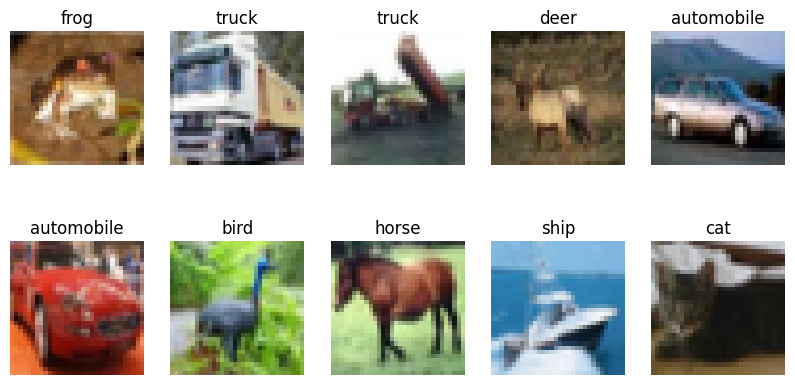

In [10]:
# Checking the labels along with the expected input

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.show()

In [11]:
# Checking class distribution

labels = y_train.flatten()
count = np.bincount(labels)

for label, item in enumerate(count):
    print(f"{label}: {item}")

0: 5000
1: 5000
2: 5000
3: 5000
4: 5000
5: 5000
6: 5000
7: 5000
8: 5000
9: 5000


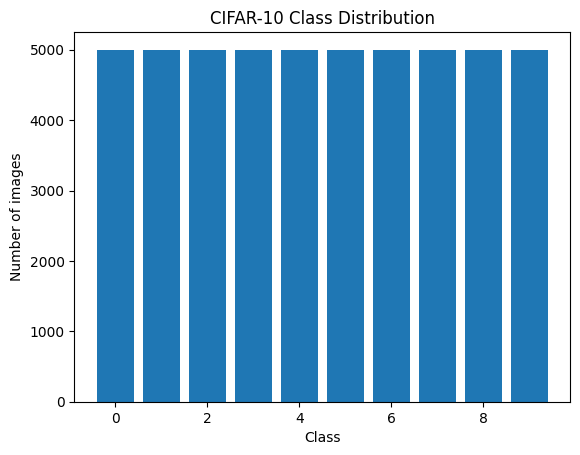

In [12]:
# Visually checking class distribution
plt.bar(range(10), count)
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.title("CIFAR-10 Class Distribution")
plt.show()

Data Augmentation

In [14]:
# Data Augmentaion Pipeline
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomTranslation(0.1,0.1),
])

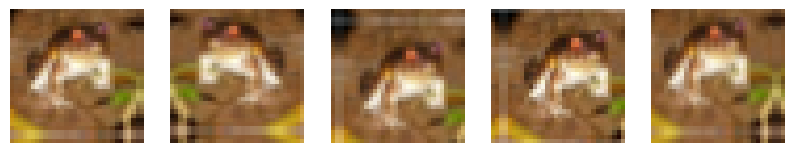

In [28]:
# Checking if augmentation is working or not
image = X_train[0]

plt.figure(figsize=(10,4))

for i in range(5):
    augmented_image = data_augmentation(image, training=True)

    plt.subplot(1, 5, i + 1)
    plt.imshow(augmented_image)
    plt.axis("off")

plt.show()

## CNN Model

In [15]:
# Model architecture

model = keras.Sequential([
    layers.Input(shape=(32,32,3)),
    
    data_augmentation, # augmenting the input image
    
    layers.Conv2D(32, (3, 3), activation="relu"), # First Convolutional Layer
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"), # Second Convolutional Layer
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(), # Flatten the feature map so that it can be use as input for dense layer

    layers.Dense(128, activation="relu"), # Dense layer
    layers.Dense(10, activation="softmax") # Output
])

In [16]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [18]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [19]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping]
)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.4284 - loss: 1.5741 - val_accuracy: 0.5472 - val_loss: 1.2610
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5568 - loss: 1.2432 - val_accuracy: 0.6240 - val_loss: 1.0619
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6054 - loss: 1.1204 - val_accuracy: 0.6648 - val_loss: 0.9680
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6329 - loss: 1.0484 - val_accuracy: 0.6668 - val_loss: 0.9729
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6477 - loss: 1.0017 - val_accuracy: 0.6858 - val_loss: 0.9151
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6624 - loss: 0.9635 - val_accuracy: 0.7066 - val_loss: 0.8496
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6723 - loss: 0.9345 - val_accuracy: 0.7072 - val_loss: 0.8520
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6852 - loss: 0.8982 

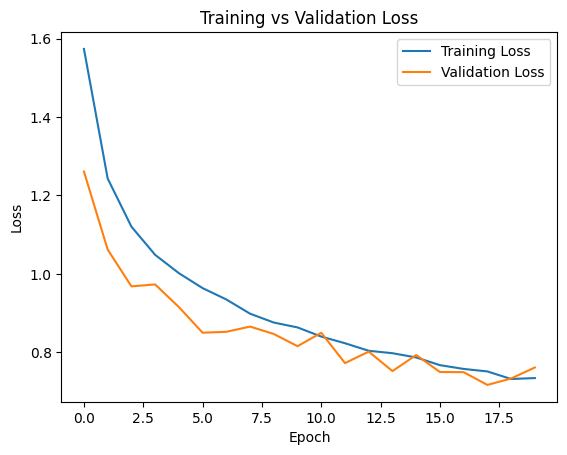

In [20]:
# Viewing the training and validation loss

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [22]:
# Evaluationg the model with test set

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    batch_size=32
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7459 - loss: 0.7364
Test Loss: 0.7363628149032593
Test Accuracy: 0.7458999752998352


In [23]:
# Checking the prediction 

predictions = model.predict(X_test)

print(predictions[0])
predicted_classes = np.argmax(predictions, axis=1)
true_classes = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[7.4023777e-04 1.9183880e-04 4.6163870e-04 8.8305163e-01 2.0062701e-04
 5.5806886e-02 5.9193797e-02 1.6103915e-04 1.5609166e-04 3.6342601e-05]


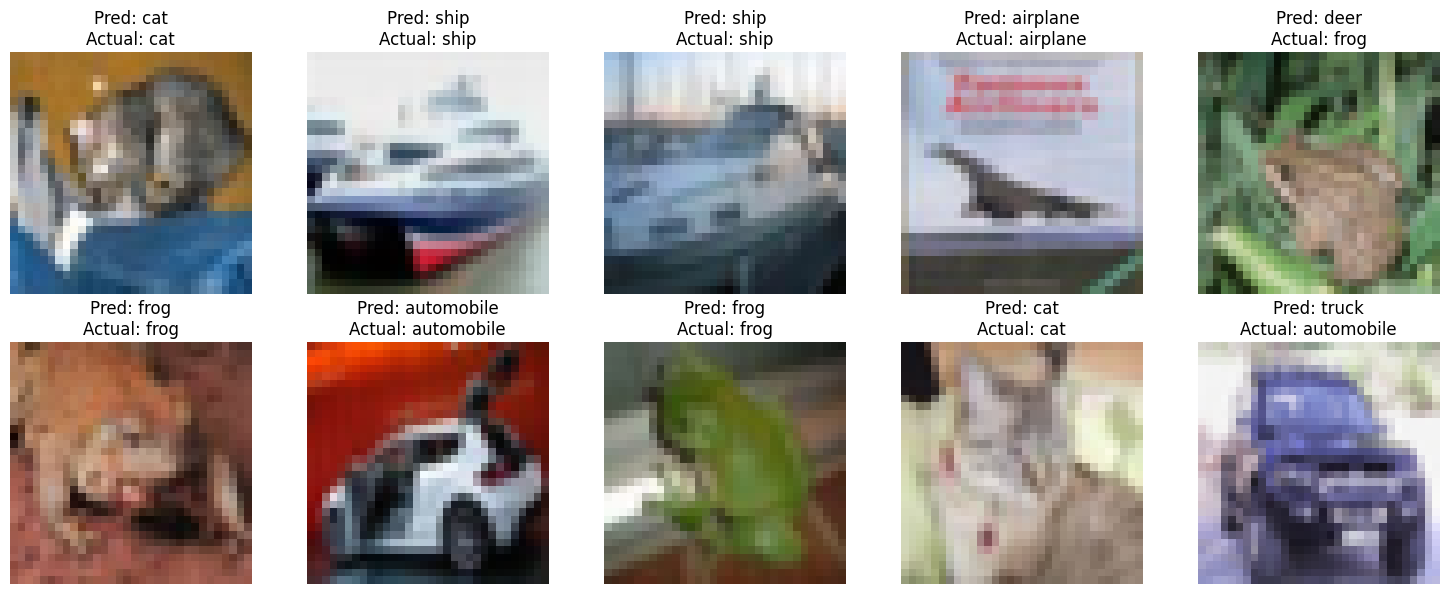

In [24]:
plt.figure(figsize=(15, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(X_test[i])
    plt.axis("off")

    predicted = class_names[predicted_classes[i]]
    actual = class_names[true_classes[i]]

    plt.title(f"Pred: {predicted}\nActual: {actual}")

plt.tight_layout()
plt.show()